**Import Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC      # Linear Support Vector Machine used for text classification
from sklearn.utils import resample

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


**Load Dataset**

In [2]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# **Data Exploration and Preprocessing**
**EDA**

In [4]:
print(f'Training dataset has {train.shape[0]} rows and {train.shape[1]} columns')
print(f'Testing dataset has {test.shape[0]} rows and {test.shape[1]} columns')

Training dataset has 31962 rows and 3 columns
Testing dataset has 17197 rows and 2 columns


In [5]:
train.head()

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [7]:
test.head()

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [8]:
train.isnull().sum()

,0
id,0
label,0
tweet,0


In [9]:
test.isnull().sum()

,0
id,0
tweet,0


In [10]:
train['label'].value_counts()    # Checking how many 0s and 1s are there in train dataset

,count
label,
0,29720
1,2242


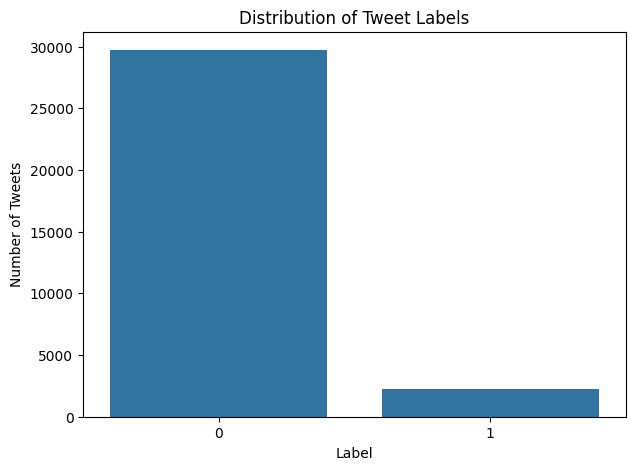


Label 0 = Non-Hate Tweet
Label 1 = Hate Tweet



In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(data=train, x='label')
plt.title('Distribution of Tweet Labels')
plt.xlabel('Label')
plt.ylabel('Number of Tweets')
plt.show()

print('''
Label 0 = Non-Hate Tweet
Label 1 = Hate Tweet
''')

In [12]:
train['tweet_lenght'] = train['tweet'].astype(str).apply(len)
train['exclamation_count'] = train['tweet'].astype(str).apply(lambda x: x.count('!'))
train['question_count'] = train['tweet'].astype(str).apply(lambda x: x.count('?'))
train['mention_count'] = train['tweet'].astype(str).apply(lambda x: len(re.findall(r"@\w+",x)))
train['hashtag_count'] = train['tweet'].astype(str).apply(lambda x: len(re.findall(r"#\w+",x)))
train['url_count'] = train['tweet'].astype(str).apply(lambda x: len(re.findall(r"http\S+|www\S+",x)))


In [13]:
display(train[[
    'tweet_lenght',
    'exclamation_count',
    'question_count',
    'mention_count',
    'hashtag_count',
    'url_count'
]].describe())

,tweet_lenght,exclamation_count,question_count,mention_count,hashtag_count,url_count
count,31962.000000,31962.000000,31962.000000,31962.000000,31962.000000,31962.000000
mean,84.739628,0.458357,0.081347,0.549747,2.387085,0.000594
std,29.455749,1.105819,0.363733,0.983729,2.501881,0.025626
min,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,63.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,88.000000,0.000000,0.000000,0.000000,2.000000,0.000000
75%,108.000000,0.000000,0.000000,1.000000,4.000000,0.000000
max,274.000000,58.000000,12.000000,11.000000,20.000000,2.000000


In [14]:
display(train.groupby('label')[[
    'tweet_lenght',
    'exclamation_count',
    'question_count',
    'mention_count',
    'hashtag_count',
    'url_count'
]].mean())

,tweet_lenght,exclamation_count,question_count,mention_count,hashtag_count,url_count
label,,,,,,
0,84.328634,0.477187,0.076077,0.528533,2.405821,0.000606
1,90.187779,0.208742,0.151204,0.830955,2.138715,0.000446


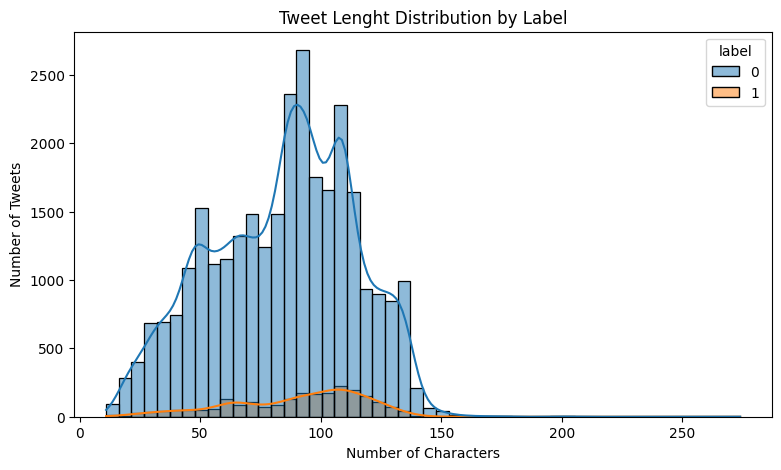

In [15]:
plt.figure(figsize=(9, 5))
plt.title('Tweet Lenght Distribution by Label (0/1)')
sns.histplot(
    data=train,
    x='tweet_lenght',
    hue='label',
    bins=50,
    kde=True
)
plt.title('Tweet Lenght Distribution by Label')
plt.xlabel('Number of Characters')
plt.ylabel('Number of Tweets')
plt.show()

**Data Cleaning**

In [16]:
def clean_text(text):
  text = str(text).lower()    # Convert all the text to lowercase
  text = re.sub(r'http\S+|www\S+',' ',text)    # Removing Urls
  text = re.sub(r'@\w+',' ',text)       # Removing Twitter mentions
  text = re.sub(r'#','',text)      # Removing hashtag
  text = re.sub(r'[^a-zA-Z\s]',' ',text)   # Removing numbers, punctuation and other special characters
  text = re.sub(r'\s+',' ',text).strip()    # Removing multiple spaces with one space
  return text

In [17]:
train['clean_tweet'] = train['tweet'].apply(clean_text)    # Applying Cleaning function to all the tweets

In [18]:
all_words = ' '.join(train['clean_tweet']).split()   # Converting all cleaned tweets into one large text and splitting into words
word_counts = Counter(all_words)     # Counting frequency of every word occur in that large text
common_words = pd.DataFrame(word_counts.most_common(20), columns=['Word','Count'])   # Converting into Dataframe with only 20 common words
print('Most Common words in the Dataset:')
common_words

Most Common words in the Dataset:


,Word,Count
0,the,10238
1,to,9866
2,i,7622
3,a,6546
4,you,5949
5,and,4945
6,in,4704
7,for,4510
8,of,4261
9,is,4196


In [20]:
# Most Common Hashtags
hashtags = []
for tweet in train['tweet'].astype(str):
  hashtags.extend(re.findall(r'#\w+',tweet.lower()))
hashtags_counts = Counter(hashtags)
hashtags_counts.most_common(10)

[('#love', 1542),
 ('#positive', 874),
 ('#healthy', 571),
 ('#smile', 548),
 ('#thankful', 491),
 ('#fun', 434),
 ('#life', 406),
 ('#summer', 367),
 ('#model', 365),
 ('#affirmation', 363)]

# **Model Building and Training**

In [27]:
train.shape

(31962, 10)

In [24]:
# We Spliting before balancing the classes to prevent duplicate samples created during upsampling
x = train['tweet']
y = train['label']
x_train, x_val, y_train, y_val = train_test_split(x, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print(f'Training samples: {len(x_train)}')
print(f'Validation samples: {len(x_val)}')


Training samples: 25569
Validation samples: 6393


In [25]:
print(y_train.value_counts())   # Training label distribution
print(y_val.value_counts())     # Validation label distribution

label
0    23775
1     1794
Name: count, dtype: int64
label
0    5945
1     448
Name: count, dtype: int64


In [28]:
# Balancing Only the Training Data
training_data = pd.DataFrame({
    'tweet': x_train,
    'label' : y_train
})        # Combining training tweets and labels into a dataframe (i.e 25569 samples)

In [29]:
majority = training_data[training_data['label'] == 0]   # Select Majority Class
minority = training_data[training_data['label'] == 1]   # Select Minority Class

In [30]:
# Increasing the minority class until it has the same number
# of examples as the majority class
minority_upsampled = resample(
    minority,
    replace=True,      # Upsampling with Replacement
    n_samples=len(majority),
    random_state=42
)
balanced_train = pd.concat([majority, minority_upsampled])    # Combining majority and minority_upsampled classes together
balanced_train = balanced_train.sample(frac=1, random_state=42)     # Shuffle the balanced dataset so that the classes are mixed

In [33]:
balanced_train['label'].value_counts()
# Now you can see label 1 was before 1794 and now 23775 thats what upsampling is!

,count
label,
0,23775
1,23775


In [34]:
# Preparing balanced training variables
x_train_balanced = balanced_train['tweet']   # Balanced tweets become our final training inputs
y_train_balanced = balanced_train['label']   # Balanced labels become or training targets

## **Model Building**

In [35]:
models = {
    'Logistic Regression':Pipeline([
        (
            'tfidf',
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1,2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
          ),     # Converting tweets into word-level TF-IDF features
         (
             'model',
             LogisticRegression(
                 max_iter=1000,   # Trainin a Logistic Regression classifier
                 random_state=42
                 )
               )
            ]),

            'Linear SVM': Pipeline([
                (
                    'tfidf',
                    TfidfVectorizer(
                        lowercase=True,
                        ngram_range=(1, 2),
                        min_df=2,
                        max_df=0.95,
                        sublinear_tf=True
                    )
                ),  # Converting tweets into TF-IDF features
                (
                    'model',
                    LinearSVC(
                        random_state=42
                    )
                 )      # Training a Linear Support Vector Machine
             ]),

    'SGD Classifier':Pipeline([
        (
            'tfidf',
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )   # Converting tweets into TF-IDF features
        ),
        (
            'model',
            SGDClassifier(
                loss='hinge',
                max_iter=1000,
                random_state=42
            )  # Training an SGD-based Linear Classifier
        )
    ])
}

**Training and Comparing Models**

In [37]:
results = []
trained_models = {}

for model_name, model in models.items():
  print(f"\n",'=' * 60)
  print('Training:',model_name)
  print('Training Completed')
  print('=' * 60)

  model.fit(      # Training current model using ONLY balanced training data
      x_train_balanced,
      y_train_balanced
  )
  validation_predictions = model.predict(x_val)     # Making predictions on untouched validation dataset

# Calculating accuracy
# We are cheching accuracy, precision etc by comapring our predictions on x_val 'validation_predictions' and y_val
# To check how accurate those predictions are!
  accuracy = accuracy_score(
      y_val,
      validation_predictions
  )
  # Calculating precision
  precision = precision_score(
      y_val,
      validation_predictions,
      zero_division=0
  )
  # Calculating Recall
  recall = recall_score(
      y_val,
      validation_predictions,
      zero_division=0
  )
  # Calculating F1-Score (Important one)
  f1 = f1_score(
      y_val,
      validation_predictions,
      zero_division=0
  )

  results.append({
      'Model':model_name,
      'Accuracy':accuracy,
      'Precision':precision,
      'Recall':recall,
      'F1-Score':f1
  })

  trained_models[model_name] = model    # Storing the trained model for later use


Training: Logistic Regression
Training Completed

Training: Linear SVM
Training Completed

Training: SGD Classifier
Training Completed


In [41]:
# Displaying Model Comparison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(
    by='F1-Score',
    ascending=False
)
print('Model Comparison: ')
display(results_df)

Model Comparison: 


,Model,Accuracy,Precision,Recall,F1-Score
1,Linear SVM,0.967152,0.876582,0.618304,0.725131
2,SGD Classifier,0.961677,0.732265,0.714286,0.723164
0,Logistic Regression,0.956046,0.668008,0.741071,0.702646


In [42]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print('Best Model: ',best_model_name)

Best Model:  Linear SVM


In [43]:
best_predictions = best_model.predict(x_val)
print('Classification Report: ')
print(classification_report(
    y_val,
    best_predictions,
    zero_division=0
))

Classification Report: 
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5945
           1       0.88      0.62      0.73       448

    accuracy                           0.97      6393
   macro avg       0.92      0.81      0.85      6393
weighted avg       0.97      0.97      0.96      6393



**Error Analysis**

In [ ]:
# True Negative  -> correctly predicted class 0
# False Positive -> class 0 incorrectly predicted as class 1
# False Negative -> class 1 incorrectly predicted as class 0
# True Positive  -> correctly predicted class 1

In [44]:
validation_results = pd.DataFrame({
    'tweet':x_val.values,
    'actual':y_val.values,
    'predicted':best_predictions
})
# keeping only the tweets that the model classified incorrectly
errors = validation_results[validation_results['actual'] != validation_results['predicted']]
print('Number of validation errors: ',len(errors))
print('Sample misclassified tweets: ')
display(errors.head(20))

Number of validation errors:  210
Sample misclassified tweets: 


,tweet,actual,predicted
142,the immature @user is just trying to make a fo...,1,0
162,"""yapping"" is right... # idiot #trump",0,1
168,president #woodrowwilson held a private screen...,1,0
199,.@user my gf used uber without forcing languag...,1,0
203,note for those who call #wn for opposing the ...,1,0
228,@user painful truth-another gunman w hate ideo...,0,1
275,@user @user @user rightly so! gop hates trump ...,0,1
317,a classic trump follower.,0,1
345,#millennials still #not by #prospect of '#wo...,0,1
441,"#nigelfarage: ""for too many years any criticis...",1,0


In [45]:
# Preparing the final Test Data
test.head()   # Remember theres no label in test.csv so we are going to predict those labels with our best model

,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedic...
1,31964,@user #white #supremacists want everyone to s...
2,31965,safe ways to heal your #acne!! #altwaystohe...
3,31966,is the hp and the cursed child book up for res...
4,31967,"3rd #bihday to my amazing, hilarious #nephew..."


In [46]:
x_test_final = test['tweet']   # Extracting tweets from test.csv
test_predictions = best_model.predict(
    x_test_final   # Using our selected best model to classify every tweet in test.csv
)

In [47]:
# Creating the submission DataFrame file
submission = pd.DataFrame({
    'id':test['id'],
    'label':test_predictions
})
print('\nSample final predictions:')
display(submission.tail(10))


Sample final predictions:


,id,label
17187,49150,0
17188,49151,1
17189,49152,0
17190,49153,0
17191,49154,0
17192,49155,1
17193,49156,0
17194,49157,0
17195,49158,0
17196,49159,0


In [48]:
submission['label'].value_counts()

,count
label,
0,16301
1,896


In [49]:
# Saving predictions and our 'submission' file to CSV
submission.to_csv('hate_speech_prediction.csv',
                  index=False)
print('Prediction file created successfully')

Prediction file created successfully


**Prediction Function**

In [50]:
def predict_tweet(tweet):
  prediction = best_model.predict([tweet])[0]   # Sending the tweet thru the complete trained pipeline

  if prediction == 1:
    return 'Hate/Offensive Tweet'

  else:
    return 'Non-Hate Tweet'

In [51]:
example_tweet = 'I hate how bad person you are'

print('Example Prediction: ')
print(predict_tweet(example_tweet))

Example Prediction: 
Hate/Offensive Tweet


In [52]:
example_tweet2 = 'That guy is humble like Leo Messi'

print('Example Prediction: ')
print(predict_tweet(example_tweet2))

Example Prediction: 
Non-Hate Tweet


# **Hate Speech Detection Using Twitter Data**

### **Project Summary**

This project develops a **Hate Speech Detection System** using **Natural Language Processing (NLP)** and machine learning. The goal is to analyze tweets and automatically classify them into two categories: **Non-Hate/Normal Tweet (0)** and **Hate/Offensive Tweet (1)**.

### **Dataset Overview**

| Feature | Description                                        |
| ------- | -------------------------------------------------- |
| `tweet` | Text content of the tweet                          |
| `label` | Target class: `0 = Non-Hate`, `1 = Hate/Offensive` |
| `id`    | Identifier for the tweet in the test dataset       |

The project begins with exploratory data analysis to understand the dataset, including its size, columns, missing values, duplicate tweets, and the distribution of the two labels. Additional text-based features such as **tweet length, exclamation marks, question marks, mentions, hashtags, and URLs** are also examined to understand differences between the two classes.

The tweet text is then cleaned by converting it to lowercase, removing URLs and mentions, removing unnecessary special characters, and keeping meaningful words. Common words and hashtags are also analyzed to understand which terms occur most frequently in the dataset.

For machine learning, the text is converted into numerical **TF-IDF features**. TF-IDF gives greater importance to words that are useful for distinguishing between tweets while reducing the importance of words that appear very frequently.

The labelled data is divided into **80% training data and 20% validation data**, while maintaining the original class distribution. Since the dataset contains considerably fewer hate/offensive tweets than normal tweets, the minority class is **upsampled only within the training data** to create a more balanced training set. The validation data remains untouched so that the evaluation represents unseen data.

Three classification models were trained and compared:

| Model               |   Accuracy |  Precision |     Recall |   F1-Score |
| ------------------- | ---------: | ---------: | ---------: | ---------: |
| **Linear SVM**      | **96.72%** | **87.66%** |     61.83% | **72.51%** |
| SGD Classifier      |     96.17% |     73.23% | **71.43%** |     72.32% |
| Logistic Regression |     95.60% |     66.80% | **74.11%** |     70.26% |

Based on the **F1-score**, the **Linear SVM** was selected as the best-performing model, with an accuracy of **96.72%** and an F1-score of **72.51%**.

### **Best Model Performance**

The Linear SVM achieved the following validation results:

| Class              | Precision | Recall | F1-Score |
| ------------------ | --------: | -----: | -------: |
| Non-Hate (0)       |      0.97 |   0.99 |     0.98 |
| Hate/Offensive (1) |      0.88 |   0.62 |     0.73 |

The overall validation accuracy was **96.72%**. The model performs particularly well at identifying Non-Hate tweets, while detecting Hate/Offensive tweets is more challenging. The **62% recall for class 1** means that the model identifies a little over half of the actual hate/offensive tweets, so there is still room for improvement in detecting this minority class.

The project also performs **error analysis** by examining incorrectly classified tweets. This helps identify examples that the model finds difficult to distinguish and can provide insight into areas where the text-processing or modelling approach could be improved.

Finally, the selected Linear SVM model is used to predict labels for the unseen `test.csv` dataset. The predictions are stored together with the tweet IDs in **`hate_speech_predictions.csv`**, providing the final output of the project.

### **Conclusion**

This project demonstrates a complete **text classification workflow**, starting with exploratory data analysis and text cleaning, followed by TF-IDF feature extraction, class balancing, model training, model comparison, evaluation, and final prediction. Among the three models tested, **Linear SVM performed best according to F1-score**, achieving **96.72% accuracy and a 72.51% F1-score** on the validation data.
